In [ ]:
import numpy as np
import sympy as sy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.linear_model import LinearRegression

<center><h1><b>Gradient Descent</b></h1></center>

- Kushal Kharel

At it's heart.  Gradient Descent is an optimization algorithm used to minimize a function. If you imagine standing on top of a foggy mountain and the goal is to reach the lowest point in the valley, gradient descent is the strategy of feeling the slope beneath the feet and taking a step in the direction where the ground drops away most steeply.

In machine learning, we use a *Cost Function or Loss Function* to measure how wrong our model's prediction are. We want this error to be as small as possible and one of the way to obtain this is to use gradient descent algorithm.

Here is the intuitive steps of gradient descent:
- From the top of the foggy mountain, look around and find the sport where the slope feels the steepest going down.
- Take a small step in that direction
- Feel the slope again and repreat the process over and over again until you reach the bottom where the ground is flat.



Note that if the steps are too big, we migh jump right past the bottom and end up on the other side of the hill. If the steps are too small, it will take very long time to get to the bottom. The goal is to find a good step size to move as quickly as possible without overshooting the target.

Gradient descent helps us deterimine the optimal model paramters (coefficients) that monomize a given cost function. There are several variants of gradient descent and the most common are batch, stochastic and mini-batch.

*Batch gradient descent*, often called vanilla gradient descent, computes the gradient of the cost function using the entire training dataset. The model's parameters are updated only after all examples have been processed. This full pass over the data is known as the epoch.

*Stochastic  Gradient Descent (SGD)* updates the model paramters after evaluating each individual training example. Although this introduces more noise into the optimization process, it can help overshoot local minima in some cases compared to batch gradient descent.

*Mini-batch Gradient Descent* combines the strengths of both methods. It divides the training data into small batches and updates the model after processing each batch. This approach offers a good balance between the stability of batch gradient descent and the speed of stochastic gradient descent, making it the most commonly used variant in practice.


Assume we have a cost function $J(\theta)$, where $\theta$ represents the parameters (weights) of our model. Our goal is to find a parameter vector $\theta \in \mathbb{R}^d$ that minimizes a objective function $J(\theta)$

$$
\min_{\theta \in \mathbb{R}^d} J(\theta)
$$

In a standard linear regression context, the cost function (Mean Squared Error) is defined as:

$$
J_{\theta} = \frac{1}{2n} \sum_{i=1}^n (h_{\theta}(x_i) - y_i)^2
$$

where:
- $n$ is the number of training examples
- $h_{\theta}(x)$ is the hypothesis (prediction).

The gradient is a vector of partial derivatives with respect to each paramter $\theta_j$. It points in the direction of the steepest ascent. To minimze the function, we move in the opposite direction.

The gradient of the vector $\nabla J(\theta)$ is defined as:

$$
\nabla J(\theta) = \begin{bmatrix} \frac{\partial J(\theta)}{\partial \theta_0} \\ \frac{\partial J(\theta)}{\partial \theta_1} \\ \vdots \\ \frac{\partial J(\theta)}{\partial \theta_n} \end{bmatrix}
$$

The core of the algorithm is the iterative update. We update all the paramters $\theta_j$ simultaneouly for each stp:

$$
\theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j}J(\theta)
$$

where:
- $\alpha$ is the learning rate( a scalar)
- $\frac{\partial}{\partial \theta_j}J(\theta)$ us the partial derivative of the cost function with respect to the specific parameter $\theta_j$.

Mathematically, the algorithm follows these steps until convergence:

- Initialize $\theta$
- Compute the gradient of the cost function at the current point
- Update parameters
$$
\theta_{next} = \theta_{current} - \alpha \nabla J (\theta_{current})
$$
- Repeat until the change in cost is smaller than a pre-defined threshold $(\epsilon)$ or a maximum number of iterations is reached
$$
|J(\theta_{next} - J(\theta_{current}))| < \epsilon
$$

In modern machine learning, we do not update the parameters one by one in a loop. We use matrix calculus for efficiency. For a linear model $Y = X\theta$, the vectorized gradient update is:

$$
\theta := \theta - \frac{\alpha}{n} X^T(X\theta - Y)
$$
where:
- X is the input feature matrix
- Y is the vector of target values
- X^T is the transpose of X



The definition above is for Batch Gradient Descent, often also called "Plain Vanilla" Gradient Descent. It is considered "vanilla" because it follows the purest form of the logic that is calculating the exact gradient of the cost function using the entire dataset before making a single update to the parameters.

While mathematically elegant, it has its limitations which lead to other variants.

- Because it sums the error over every single training example for one update, it is computationally "expensive" if we have million rows of data
- It requires all data to fit into computer's memory at once to compute the gradient.

If we are to modify the "vanilla" math slightly, we get the other variants.

- *Stochastic Gradient Descent (SGD)*: Instead of $\frac{1}{n} \sum_{i=1}^n$, we pick one random index $i$ and update $\theta$ based only on that single error:
$$
\theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j} J(\theta; x_i, y_i)
$$

- *Mini-Batch Gradient Descent*: Instead of 1 or $n$, we use a small set $b$ (e.g., 32 samples). This is what almost everyone uses in the real world.

$$
\theta_j := \theta_j - \alpha \frac{1}{b} \sum_{i=1}^b \nabla J_i(\theta)
$$

Now let's look at coding examples of Gradient Descent Method

**Univariate Case**

Let's look at the example of single variable case. Suppose the function is given by

$$
f(x) = x^2
$$

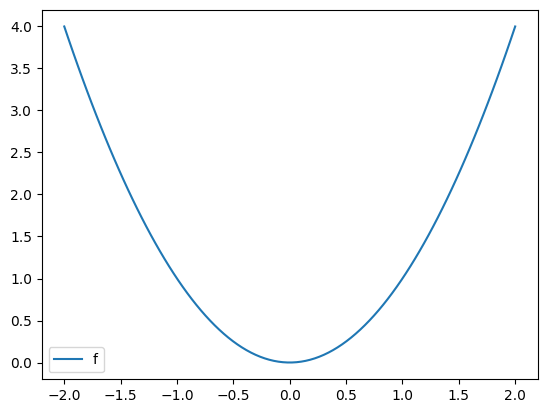

In [ ]:
def f(x):
  return x**2

x = np.linspace(-2, 2, 100) # domain of x

plt.plot(x, f(x), label='f')
plt.legend()
plt.show()

The gradient of the given function is,

$$
\nabla f(x) = 2x
$$

Let's figure out the exact minimum using brute force to try out bunch of x values and return the one that yields the lowest loss.

In [ ]:
def minimize(f, x_values):
  y = [f(x) for x in x_values]
  return x_values[np.argmin(y)]

In [ ]:
xs = np.linspace(-2,2,20)
sparse_xs =  np.linspace(-2,2,20)

ys = f(xs)
sparse_ys = f(sparse_xs)
print('Brute Force minimum', minimize(f = f, x_values = xs))

Brute Force minimum 0.10526315789473673


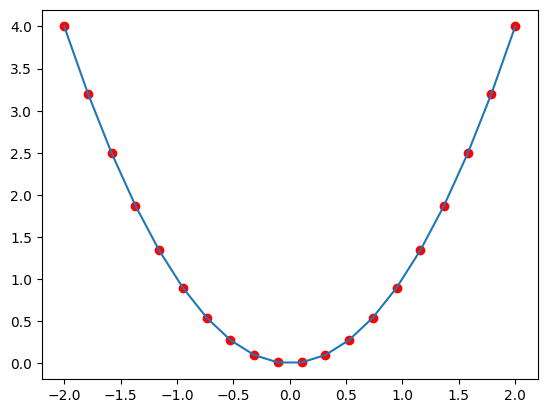

In [ ]:
plt.plot(xs, f(xs))
plt.scatter(sparse_xs, f(sparse_xs), color = 'r')
plt.show()

This brute force approach suffers from three major flaws:

1) If the minimum is outside our range of values, the answer will be completely wrong

2) Even if our range of values is correct, if the values are too coarse, our answers will be inaccurate

3) It is absurdly computationally inefficient considering potentially vast number of values that are useless.

Instead of choosing all values ahead of time, we can instead start from a single value and try to interatively improve it.

Alternative approach is to use the derivative of the function we are trying to optimize as a guide.

If the derivative of the funciton is negative, that means the function is decreasing, so we should go to the right(pick a bigger x).

If the derivative of the function is positive, that means the function is increasing so we should go to the left.

The derivative tells use which way to go.

In [ ]:
def derivative(x):
  return 2*x

def line(x):
  return (0*x)

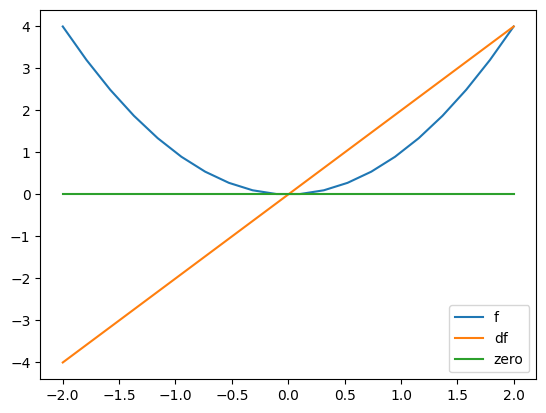

In [ ]:
plt.plot(xs, f(xs), label = 'f')
plt.plot(xs, derivative(xs), label = 'df')
plt.plot(xs, line(xs), label = 'zero')
plt.legend()
plt.show()

Where there is a crossing point of 0, we can have minima or maxima of our functions. We will use gradient descent to identify a point where the derivative is zero.

Let's try to iteratively use the derivative in finding maximum or minimum values of a function.  We will use a numeric approximation for the derivative (slope of tangent line) and write the equation for this line.  Then, use this line to approximate a value of the function a short distance from the point of tangency.

The approximation of the derivative $f'$ of above function $f$ is given by

$$
f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}
$$

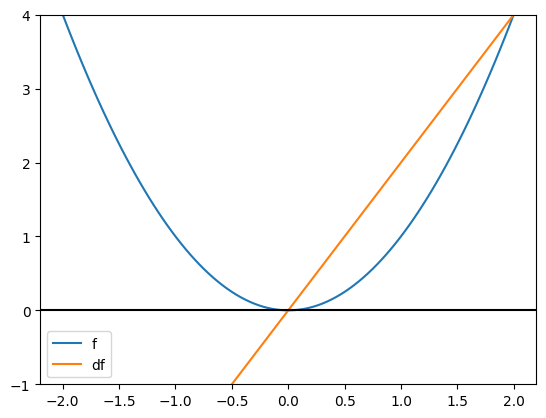

In [ ]:
def df(x):
  return (f(x+0.0001) - f(x))/0.0001

plt.plot(x, f(x), label = 'f')
plt.plot(x, df(x), label='df')
plt.ylim(-1,4)
plt.axhline(color='black')
plt.legend()
plt.show()

Suppose we want the tangent at x = 1.

The point-slope form for a line is given by,

$$
y = m(x-x_0) + y_0
$$

where $m$ = slope, and $(x_0, y_0) = (x, f(x))$

In [ ]:
x1 = 1
y1 = f(x1)
m = df(x1)
print(f'The slope of a line at point {(x1, y1)} is {m}')
print(f' The point-slope form at point {(x1, y1)} is: y - {y1:.3f} = {m:.3f}(x - {x1})')


The slope of a line at point (1, 1) is 2.000099999999172
 The point-slope form at point (1, 1) is: y - 1.000 = 2.000(x - 1)


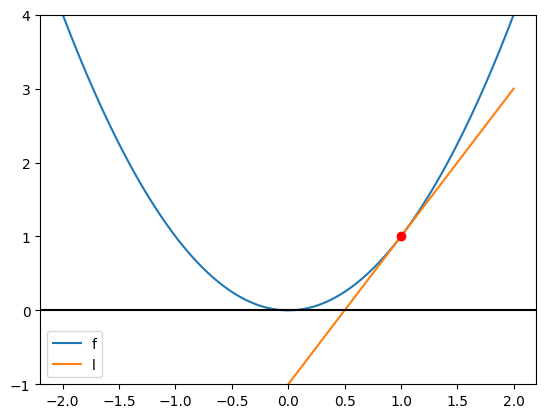

In [ ]:
def l(x):
  return m*(x - 1) + 1

plt.plot(x, f(x), label = 'f')
plt.plot(x, l(x), label = 'l')
plt.plot(1, 1, 'ro')
plt.ylim(-1,4)
plt.axhline(color='black')
plt.legend()
plt.show()

Now we will use the equation of the tangent line to approximate the value OF $f(x)$ at $x = 0.9$.

The error will be the absolute difference between this value and the actual value of $f(0.9)$.

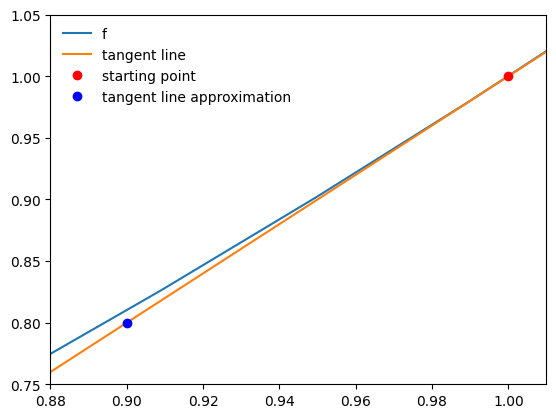

In [ ]:
f_next = l(0.9)
error = abs(f_next - f(0.9))

plt.plot(x, f(x), label = 'f')
plt.plot(x, l(x), label = 'tangent line')
plt.plot(1, 1, 'ro', label = 'starting point')
plt.plot(0.9, l(0.9), 'bo', label = 'tangent line approximation')
plt.ylim(0.75, 1.05)
plt.xlim(0.88, 1.01)
plt.axhline(color = 'black')
plt.legend(frameon = False);


Now, after understanding the above concepts we will implement the gradient descent algorithm.

In [ ]:
def gradient_descent(f, df, x_init, learning_rate=0.1, n_iter=1000, tol=1e-6):
  """
  Gradient descent with convergence check for scalar or vector x.
  """
  # If scalar, just assign directly; if array, copy
  if isinstance(x_init, (int, float)):
      x = x_init
      history = [x]
  else:
      x = x_init.copy()
      history = [x.copy()]

  for i in range(n_iter):
      grad = df(x)
      x_new = x - learning_rate * grad
      history.append(x_new if isinstance(x, (int,float)) else x_new.copy())

      # Convergence check
      if np.linalg.norm(x_new - x) < tol:
          print(f"Converged after {i+1} iterations")
          return np.array(history), True

      x = x_new

  print("Reached maximum iterations without full convergence")
  return np.array(history), False


Let's look at the trajectory on the function curve

Converged after 18 iterations


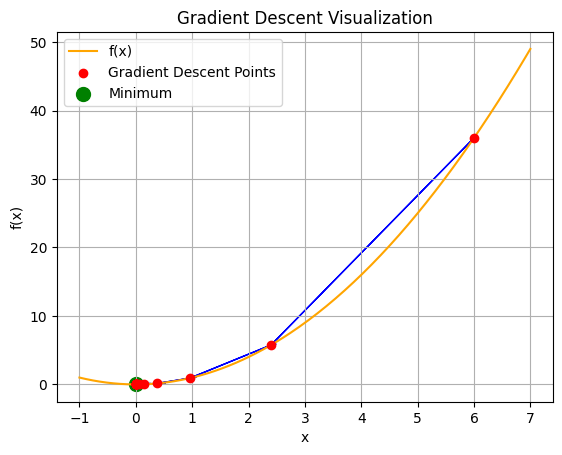

In [ ]:
# Run gradient descent
trajectory, converged = gradient_descent(f, df, x_init=6, learning_rate=0.3, n_iter=100)

# Plot function
x_vals = np.linspace(-1, 7, 200)
plt.plot(x_vals, f(x_vals), label='f(x)', color='orange')

# Plot gradient descent points
plt.scatter(trajectory, f(trajectory), color='red', zorder=5, label='Gradient Descent Points')

# Draw arrows between points
for i in range(len(trajectory)-1):
  x0, x1 = trajectory[i], trajectory[i+1]
  y0, y1 = f(x0), f(x1)
  dx = x1 - x0
  dy = y1 - y0
  # Scale arrows for visibility if steps are small
  plt.arrow(x0, y0, dx, dy, head_width=0.15, head_length=0.15, fc='blue', ec='blue', length_includes_head=True)

# Highlight minimum
x_min = trajectory[-1]
plt.scatter(x_min, f(x_min), color='green', s=100, label='Minimum')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Gradient Descent Visualization')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
trajectory, converged = gradient_descent(f, df, x_init=6.0, learning_rate=0.3, n_iter=100)

print("Final x:", trajectory[-1])
print("f(x) at final x:", f(trajectory[-1]))
print("Converged:", converged)


Converged after 18 iterations
Final x: -4.9587679703610424e-05
f(x) at final x: 2.458937978387857e-09
Converged: True


We can use scipy minimize function to find the minimum as well. See below,

In [ ]:
from scipy.optimize import minimize

minimize(f, x0 = 6)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 4.3062399964319126e-16
        x: [-2.075e-08]
      nit: 3
      jac: [-2.660e-08]
 hess_inv: [[ 5.000e-01]]
     nfev: 8
     njev: 4

We can see that library is more efficient than simple gradient descent becauses it uses smart quasi-Newton methods rather than fixed steps.

Now, let us look at the example in the case of linear regression and compare vanilla gradient descent with closed form solution

In [ ]:
# generate synthetic dataset

np.random.seed(42)
n_samples = 30000

x1 = np.random.normal(0, 1, n_samples)          # Feature 1
x2 = np.random.normal(0, 5, n_samples)          # Feature 2


beta1 = 3.0 # coefficient 1
beta2 = -0.7 # coefficient 2

noise = np.random.normal(0, 2, n_samples)

y =  beta1*x1 + beta2*x2 + noise # linear regression model


In [ ]:
X = np.column_stack([x1, x2])
y = y

In [ ]:
# Standardize the data

X_standard = (X - np.mean(X, axis=0))/np.std(X, axis =0)

In [ ]:
A = X_standard.T @ X_standard
b = X_standard.T @ y

In [ ]:
A_inverse = np.linalg.inv(A)
x = A_inverse @ b
print(f'Slope of a fitted line is:', x)

Slope of a fitted line is: [ 2.9865814  -3.49584885]


In [ ]:
# We can also achieve same slope using sklearn

lr = LinearRegression()
lr.fit(X_standard,y)

LinearRegression()

In [ ]:
lr.coef_

array([ 2.9865814 , -3.49584885])

We can see from the results that the slope of a 2D function is described by 2D vector. The best way down has two components, each corresponding to the slope with respect to two input variables. The above is our closed-form solution of linear regression model we created. Now, let's find the optimal parameters using gradient descent

In [ ]:
# to use the gradient descent function above, we need to compute the derivative of MSE, the derivative is with respect to theta

# define Mean Squared Loss
def mse_loss(theta, X, y):
  return np.mean((X @ theta - y)**2) # Note the difference in implementation

# Define the derivative of Mean Squared Loss
def mse_gradient(theta, X, y):
  return (2 / X.shape[0]) * (X.T @ (X @ theta - y)) # Note the difference in implementation and formula, think about it clearly


In [ ]:
theta_init = np.zeros(X_standard.shape[1]) # initialize thetas

theta_trajectory, converged = gradient_descent(
    f= (lambda theta: mse_loss(theta, X_standard, y)),
    df=(lambda theta: mse_gradient(theta, X_standard, y)),
    x_init=theta_init,
    learning_rate=0.1,
    n_iter=100
)

print("Final theta:", theta_trajectory[-1])
print("Converged:", converged)


Converged after 63 iterations
Final theta: [ 2.9865793  -3.49584631]
Converged: True


The coefficients found by the Normal equation and Gradient Descent are virtually identical which validates the implementation.

While the closed form solution is simple and mathematically precise, gradient descent is necessary for models that are non-linear or for linear models dealing with massive, high dimensional data. Normal equation cannot be used for non-linear models like Logistic Regression, Neural Networks or SVMs.

Gradient Descent is a universal optimization algorithm. It can be adaped to minimize any differential cost function.

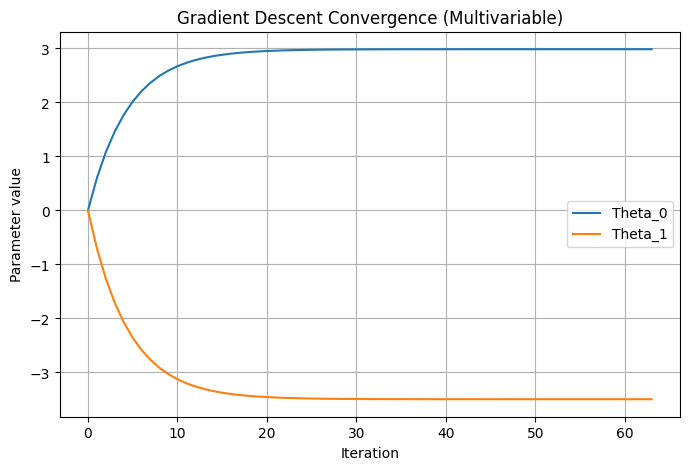

In [ ]:
# plot of theta trajectory

theta_trajectory = np.array(theta_trajectory)

plt.figure(figsize=(8,5))
for j in range(X_standard.shape[1]):
  plt.plot(theta_trajectory[:, j], label=f'Theta_{j}')
plt.xlabel('Iteration')
plt.ylabel('Parameter value')
plt.title('Gradient Descent Convergence (Multivariable)')
plt.legend()
plt.grid(True)
plt.show()


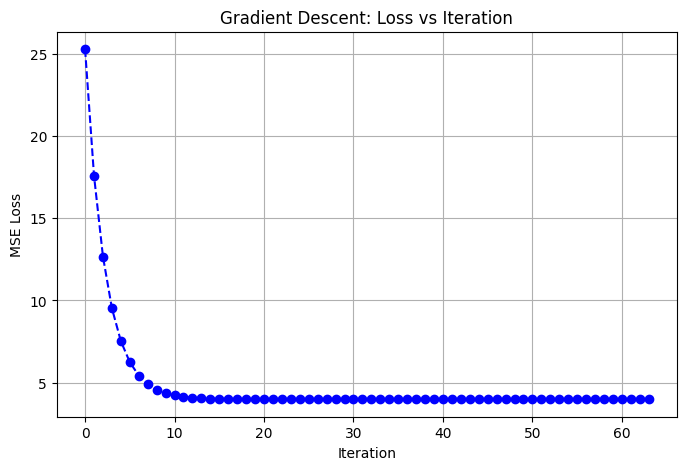

In [ ]:
# loss trajectory

loss_trajectory = [mse_loss(theta, X_standard, y) for theta in theta_trajectory]
plt.figure(figsize=(8,5))
plt.plot(loss_trajectory, '--o', color='blue')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Gradient Descent: Loss vs Iteration')
plt.grid(True)
plt.show()


In [ ]:
# Create a grid of theta values
theta0_vals = np.linspace(theta_trajectory[:,0].min()-1, theta_trajectory[:,0].max()+1, 50)
theta1_vals = np.linspace(theta_trajectory[:,1].min()-1, theta_trajectory[:,1].max()+1, 50)
Theta0, Theta1 = np.meshgrid(theta0_vals, theta1_vals)

# Compute MSE loss for each pair of theta0, theta1
Loss_surface = np.zeros_like(Theta0)
for i in range(Theta0.shape[0]):
  for j in range(Theta0.shape[1]):
    theta_temp = np.array([Theta0[i,j], Theta1[i,j]])
    Loss_surface[i,j] = mse_loss(theta_temp, X_standard, y)


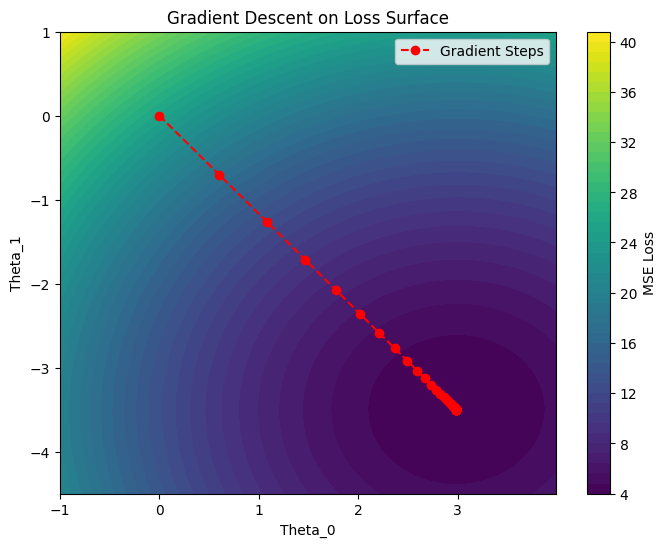

In [ ]:
# Plot contour
plt.figure(figsize=(8,6))
cp = plt.contourf(Theta0, Theta1, Loss_surface, levels=50)
plt.colorbar(cp, label='MSE Loss')
plt.plot(theta_trajectory[:,0], theta_trajectory[:,1], '--o', color='red', label='Gradient Steps')
plt.xlabel('Theta_0')
plt.ylabel('Theta_1')
plt.title('Gradient Descent on Loss Surface')
plt.legend()
plt.show()

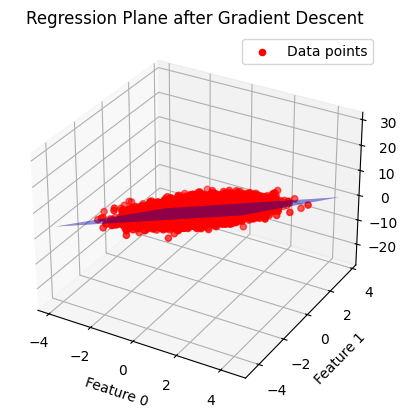

In [ ]:

x0_grid, x1_grid = np.meshgrid(
    np.linspace(X_standard[:,0].min(), X_standard[:,0].max(), 20),
    np.linspace(X_standard[:,1].min(), X_standard[:,1].max(), 20)
)
X_grid = np.column_stack([x0_grid.ravel(), x1_grid.ravel()])
y_grid = X_grid @ theta_trajectory[-1] # predicted values
y_grid = y_grid.reshape(x0_grid.shape)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_standard[:,0], X_standard[:,1], y, color='red', label='Data points')
ax.plot_surface(x0_grid, x1_grid, y_grid, alpha=0.5, color='blue')
ax.set_xlabel('Feature 0')
ax.set_ylabel('Feature 1')
ax.set_zlabel('y')
plt.title('Regression Plane after Gradient Descent')
plt.legend()
plt.show()


This plane minimizes the mean squared error (MSE) between predicted y and actual y. It is the “best-fit plane” according to linear regression.

Further exploration entails other variant of gradient descent, the plain batch GD is not scalable for large datasets. Modify the code to implement Stochastic Gradient Descent and Mini-Batch Gradient Descent